# Exploratory Data Analysis (EDA) Project

**Goal:** Analyze a dataset to uncover patterns and trends.

This notebook covers:
1. Load the dataset & inspect structure
2. Statistical summaries (numeric + categorical)
3. Univariate analysis (distributions)
4. Bivariate & correlation analysis
5. Identify key influencing factors
6. Present insights in a structured summary


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

## 1. Load & Inspect Data

In [2]:
df = pd.read_csv("../data/student_performance.csv")
print(df.shape)
df.head()

(1200, 13)


,StudentID,Gender,ParentalEducation,LunchType,TestPrepCourse,StudyHoursWeekly,AttendanceRate,ExtracurricularActivity,SleepHours,MathScore,ReadingScore,WritingScore,AverageScore
0,STU3000,Male,High School,Free/Reduced,Not Completed,6.4,98.0,No,6.4,66.2,70.5,62.2,66.3
1,STU3001,Female,High School,Free/Reduced,Not Completed,10.2,85.6,Yes,5.5,53.7,52.7,58.9,55.1
2,STU3002,Male,High School,Standard,Completed,7.7,86.7,Yes,6.5,81.2,70.7,72.5,74.8
3,STU3003,Male,High School,Standard,Not Completed,4.1,81.4,Yes,7.7,54.2,58.5,56.9,56.5
4,STU3004,Male,High School,Standard,Not Completed,9.0,92.2,No,5.3,83.7,92.3,93.5,89.8


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   StudentID                1200 non-null   str    
 1   Gender                   1200 non-null   str    
 2   ParentalEducation        1200 non-null   str    
 3   LunchType                1200 non-null   str    
 4   TestPrepCourse           1200 non-null   str    
 5   StudyHoursWeekly         1200 non-null   float64
 6   AttendanceRate           1200 non-null   float64
 7   ExtracurricularActivity  1200 non-null   str    
 8   SleepHours               1200 non-null   float64
 9   MathScore                1200 non-null   float64
 10  ReadingScore             1200 non-null   float64
 11  WritingScore             1200 non-null   float64
 12  AverageScore             1200 non-null   float64
dtypes: float64(7), str(6)
memory usage: 122.0 KB


In [4]:
print("Missing values:\n", df.isna().sum().sum(), "total")
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 0 total

Duplicate rows: 0


## 2. Statistical Summary

In [5]:
df.describe()

,StudyHoursWeekly,AttendanceRate,SleepHours,MathScore,ReadingScore,WritingScore,AverageScore
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,8.951250,79.588667,6.979333,80.791167,82.558167,79.931917,81.093250
std,5.196733,12.088910,1.184557,11.757912,11.519623,11.794948,11.004512
min,0.500000,29.700000,4.000000,40.000000,42.400000,41.900000,46.100000
25%,5.300000,72.400000,6.200000,72.800000,74.850000,72.075000,73.200000
50%,7.950000,81.500000,7.000000,81.000000,82.550000,79.900000,81.250000
75%,11.700000,88.800000,7.800000,89.400000,91.300000,88.600000,89.225000
max,36.700000,99.800000,10.000000,100.000000,100.000000,100.000000,100.000000


In [6]:
# Categorical breakdown
for col in ["Gender", "ParentalEducation", "LunchType", "TestPrepCourse", "ExtracurricularActivity"]:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).round(3))


Gender:
Gender
Male      0.501
Female    0.499
Name: proportion, dtype: float64

ParentalEducation:
ParentalEducation
High School           0.358
Associate's Degree    0.295
Bachelor's Degree     0.253
Master's Degree       0.094
Name: proportion, dtype: float64

LunchType:
LunchType
Standard        0.64
Free/Reduced    0.36
Name: proportion, dtype: float64

TestPrepCourse:
TestPrepCourse
Not Completed    0.586
Completed        0.414
Name: proportion, dtype: float64

ExtracurricularActivity:
ExtracurricularActivity
No     0.53
Yes    0.47
Name: proportion, dtype: float64


## 3. Univariate Analysis — Score Distributions

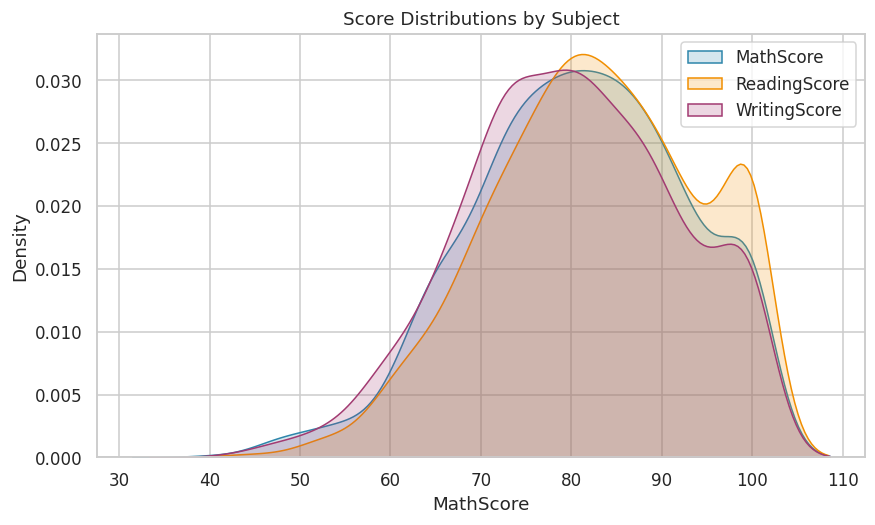

In [7]:
plt.figure(figsize=(9,5))
for col, color in zip(["MathScore", "ReadingScore", "WritingScore"], ["#2E86AB", "#F18F01", "#A23B72"]):
    sns.kdeplot(df[col], label=col, fill=True, alpha=0.2, color=color)
plt.title("Score Distributions by Subject")
plt.legend()
plt.show()

All three subject scores are roughly bell-shaped and centered around 75-85,
which suggests average scores are a reasonable single measure of overall performance for later analysis.

## 4. Correlation Analysis

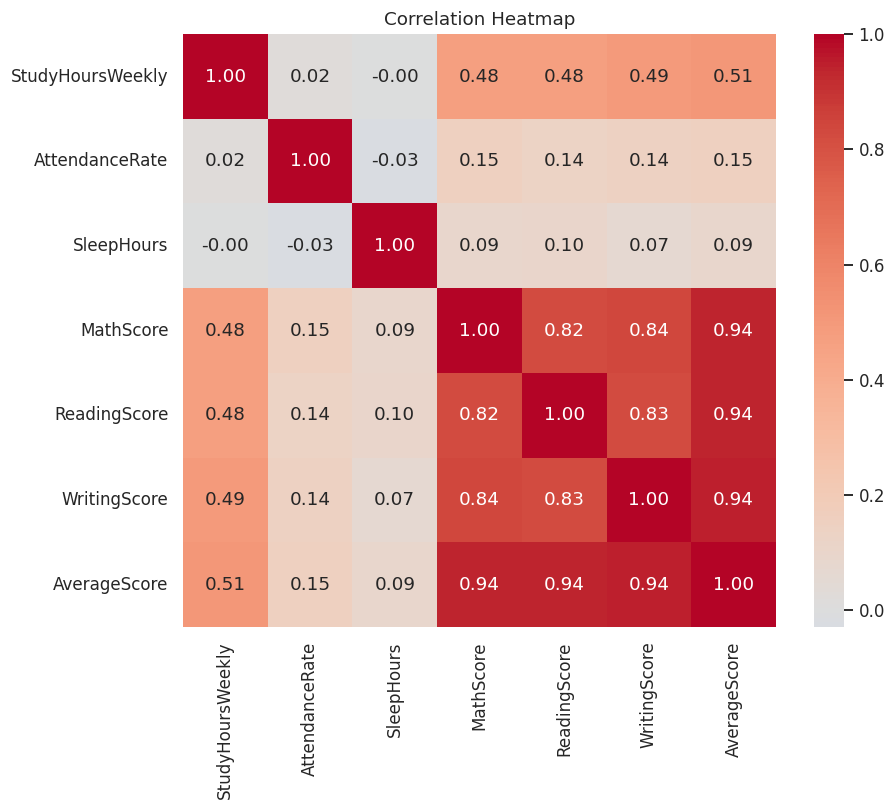

In [8]:
numeric_cols = ["StudyHoursWeekly", "AttendanceRate", "SleepHours",
                 "MathScore", "ReadingScore", "WritingScore", "AverageScore"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap")
plt.show()

In [9]:
corr["AverageScore"].sort_values(ascending=False)

AverageScore        1.000000
WritingScore        0.944644
MathScore           0.943045
ReadingScore        0.936110
StudyHoursWeekly    0.512579
AttendanceRate      0.151805
SleepHours          0.090661
Name: AverageScore, dtype: float64

## 5. Bivariate Analysis — Key Influencing Factors

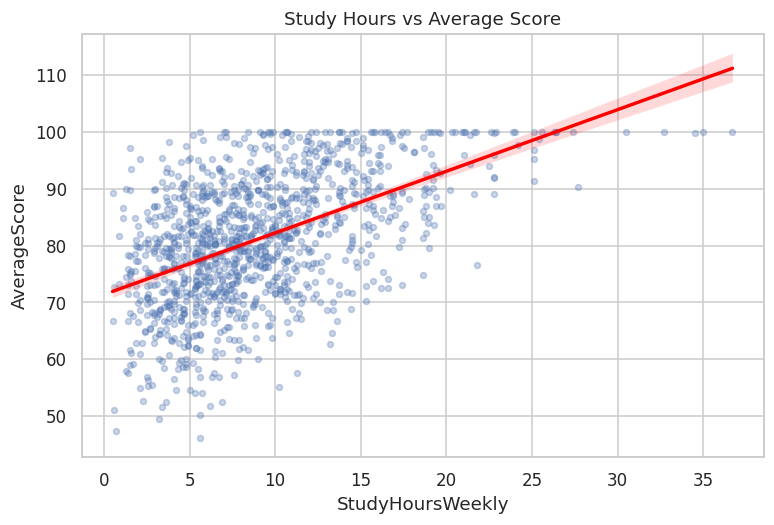

In [10]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x="StudyHoursWeekly", y="AverageScore",
            scatter_kws={"alpha":0.3, "s":15}, line_kws={"color":"red"})
plt.title("Study Hours vs Average Score")
plt.show()

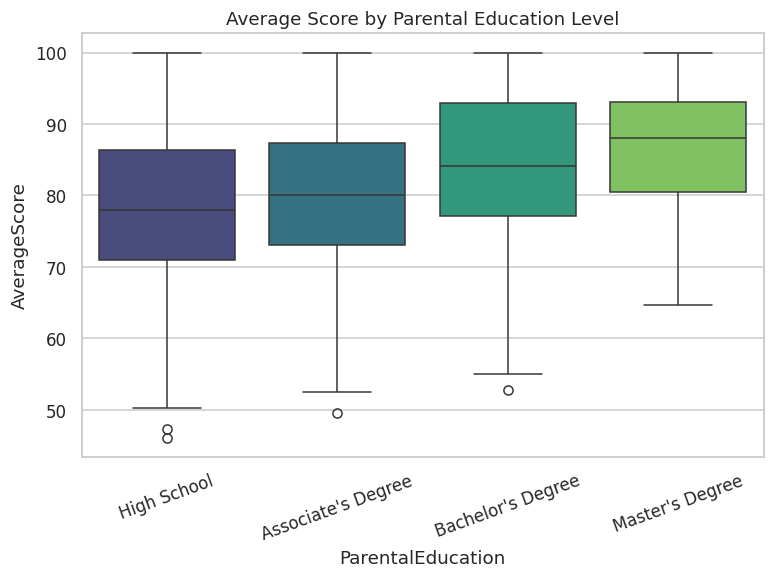

ParentalEducation
High School           78.20
Associate's Degree    79.90
Bachelor's Degree     84.49
Master's Degree       86.65
Name: AverageScore, dtype: float64

In [11]:
edu_order = ["High School", "Associate's Degree", "Bachelor's Degree", "Master's Degree"]
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="ParentalEducation", y="AverageScore", order=edu_order,
            hue="ParentalEducation", palette="viridis", legend=False)
plt.title("Average Score by Parental Education Level")
plt.xticks(rotation=20)
plt.show()

df.groupby("ParentalEducation")["AverageScore"].mean().reindex(edu_order).round(2)

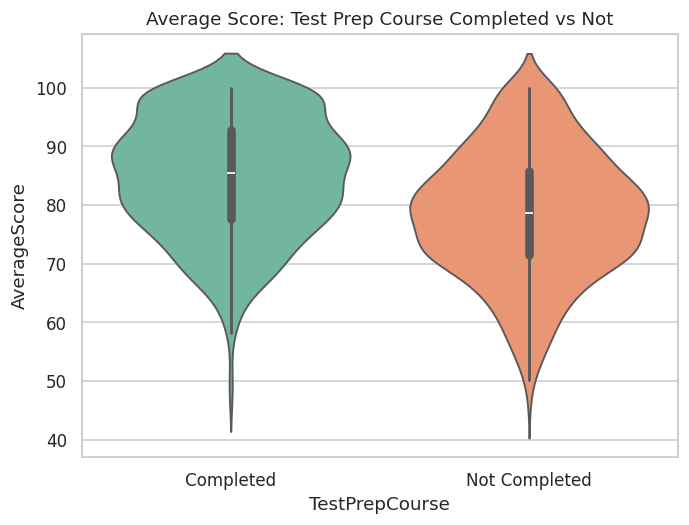

TestPrepCourse
Completed        84.81
Not Completed    78.46
Name: AverageScore, dtype: float64

In [12]:
plt.figure(figsize=(7,5))
sns.violinplot(data=df, x="TestPrepCourse", y="AverageScore",
               order=["Completed", "Not Completed"],
               hue="TestPrepCourse", hue_order=["Completed", "Not Completed"],
               palette="Set2", legend=False)
plt.title("Average Score: Test Prep Course Completed vs Not")
plt.show()

df.groupby("TestPrepCourse")["AverageScore"].mean().round(2)

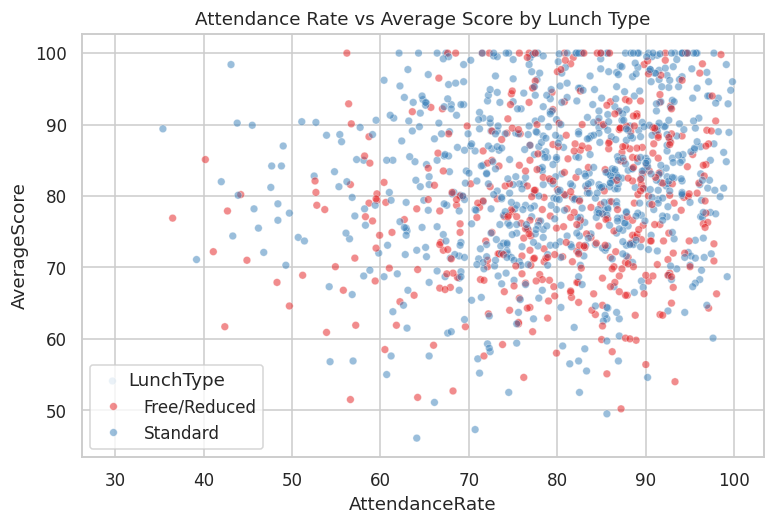

LunchType
Free/Reduced    78.85
Standard        82.35
Name: AverageScore, dtype: float64

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="AttendanceRate", y="AverageScore", hue="LunchType",
                 alpha=0.5, palette="Set1", s=25)
plt.title("Attendance Rate vs Average Score by Lunch Type")
plt.show()

df.groupby("LunchType")["AverageScore"].mean().round(2)

## 6. Key Findings

- **Subject scores are highly inter-correlated (r ≈ 0.82–0.84)** — a student who does well in Math tends to do well in Reading and Writing too, confirming `AverageScore` is a valid single performance metric.
- **Study hours is the strongest behavioral driver** of average score (r ≈ 0.51) — each additional weekly study hour is associated with a clear upward trend in scores.
- **Parental education level matters**: average scores rise steadily from High School-educated parents (78.2) to Master's-degree parents (86.7) — a nearly 8.5 point gap.
- **Completing a test-prep course adds ~6.3 points on average** (84.8 vs 78.5), the single largest "actionable" factor in the dataset — unlike parental education, this is something a student/school can directly influence.
- **Lunch type (a proxy for socioeconomic status) also matters**: students on standard lunch average 82.4 vs 78.9 for free/reduced lunch.
- **Attendance and sleep show only weak correlation** with scores (r ≈ 0.15 and 0.09) — in this dataset, consistent effort (study hours, test prep) matters more than mere presence or rest.

### Recommendation
If a school wants to raise average scores with limited resources, the data suggests **prioritizing test-prep course access and encouraging structured study habits** — these show the strongest, most actionable relationships with performance, more so than attendance policies alone.
